<div style="text-align: center; border: 3px solid #4CAF50; border-radius: 12px; padding: 25px; background-color: #f9fdf9;">

<h1 style="color: #2E86C1; font-family: 'Trebuchet MS', sans-serif; font-size: 42px;">
📘 From Neural Networks to Large Language Models
</h1>

<h2 style="color: #117A65; font-family: 'Trebuchet MS', sans-serif; font-size: 28px; margin-top: 10px;">
A Structured Learning Notebook
</h2>

<hr style="border: 1px solid #4CAF50; width: 80%;">

</div>


# Introduction

ChatGPT has a long history that starts from LSTMs and evolves through several stages. To understand ChatGPT, it helps to know how innovations in deep learning gradually solved problems in sequence modeling.

The history can be divided into five stages. In each stage:
- a new innovation was introduced,
- limitations of the previous method were addressed,
- and progress was made toward more powerful models.  

This chain of innovations eventually led to GPT. If one is curious about how ChatGPT came into the picture, how it works, and what technologies power it, studying this sequence is important.

---

## Deep Learning Modules

To study this journey systematically, the learning path can be organized into five modules:

1. **Artificial Neural Networks (ANNs)**  
   - Basics of neural networks  
   - Improving performance: regularization, dropout, early stopping  

2. **CNNs for Image Data**  
   - How convolutional networks work  
   - Transfer learning  

3. **RNNs for Sequential Data**  
   - Applying deep learning to sequential data  
   - Architectures: LSTM, GRU  

4. **Sequence-to-Sequence Models**  
   - Encoder–decoder architectures  
   - Attention mechanism  
   - Transformers and fine-tuning  

5. **Unsupervised Deep Learning**  
   - Generative Adversarial Networks (GANs)  
   - Autoencoders  

The first three modules form the foundation. The next focus is on sequence-to-sequence models, which are highly relevant in modern NLP and directly connect to LLMs like ChatGPT.

---

## Sequence-to-Sequence Models

Seq2seq models are designed for problems where both input and output are sequences, and their lengths may differ. They are especially useful when input–output mapping is asynchronous.

### RNN sequence mapping types
- **Many → One**: input is sequence, output is scalar.  
  *Example:* Sentiment analysis (movie review → positive/negative).  

- **One → Many**: input is single item, output is sequence.  
  *Example:* Image captioning (image → caption text).  

- **Many → Many (synchronous)**: input and output are sequences of equal length.  
  *Examples:* POS tagging, Named Entity Recognition.  

- **Many → Many (asynchronous)**: input and output are sequences of different lengths.  
  *Example:* Machine translation (sentence in one language → translated sentence).  

Seq2seq models were created to solve asynchronous many-to-many problems like translation.

---

## Applications of Seq2seq
- Text summarization: long document → short summary  
- Question answering: question → answer  
- Conversational AI / chatbots: dialogue → response  
- Speech-to-text: audio sequence → text sequence  

These models are powerful because they solve many challenging NLP tasks.

---

## Historical Stages

The development of seq2seq models can be divided into five important stages:

1. **Encoder–Decoder architecture (2014)**: first attempt for machine translation, but had limitations.  
2. **Attention mechanism**: improved encoder–decoder by focusing on relevant inputs.  
3. **Transformer architecture**: powerful model, the “T” in GPT.  
4. **Transfer learning in NLP**: pretraining + fine-tuning approach, led to major improvements.  
5. **Large Language Models (LLMs)**: final stage, with ChatGPT as a leading example.

Studying these stages step by step builds the right perspective before diving into detailed architectures.


# Stage 1: Encoder–Decoder Architecture (2014)

The story begins in 2014, when researchers introduced a new way to solve sequence-to-sequence problems. They published a seminal paper titled *“Sequence to Sequence Learning with Neural Networks”*. This work became very popular because it proposed a simple and elegant solution to sequence learning problems, especially machine translation.

---

## Idea of Sequence-to-Sequence (Seq2Seq)

- In seq2seq tasks, the goal is to map an **input sequence** to an **output sequence**.  
- Example: English to Hindi translation  
  - Input: *I love India*  
  - Output: *मुझे भारत से प्यार है*

The architecture is divided into two parts:
1. **Encoder**  
   - Reads the input sequence word by word.  
   - Compresses all the information into a single fixed-length vector (called the *context vector*).  

2. **Decoder**  
   - Takes the context vector as input.  
   - Generates the output sequence step by step.  
   - Example: produces “मुझे → भारत → से → प्यार → है” in order.

---

## What’s inside Encoder and Decoder?

- Both encoder and decoder are built using **RNN cells**.  
- The paper used **LSTM cells**, but GRUs or vanilla RNNs can also be used.  
- Working:  
  - At each timestep, the LSTM updates its hidden state and cell state.  
  - After the last input word, the final state acts as the **compressed representation** of the entire sentence.  
  - This representation is passed to the decoder, which then generates the output word by word.

---

## Example Flow

1. Input sentence: *Transformers are great*  
2. Words are fed one by one into the encoder LSTM.  
3. Hidden states keep updating, summarizing the information.  
4. After the last word, the final state = **context vector**.  
5. Decoder LSTM takes this vector and generates output sequence (e.g., translated sentence in German).

---

## Strengths and Weaknesses

- **Strength**:  
  - Works well for **short sentences**.  
  - Can successfully translate small sequences.  

- **Weakness**:  
  - Fails with **long sentences or paragraphs**.  
  - Problem: the entire meaning must be stored in a single context vector.  
  - As sentence length grows, the model tends to **forget early words** (memory loss).  
  - Translation loses accuracy and often produces meaningless output.  

This limitation of relying on a single fixed-length context vector highlighted the need for a new mechanism.  
That mechanism was later introduced as the **Attention Mechanism**, which solved the memory bottleneck problem.

---


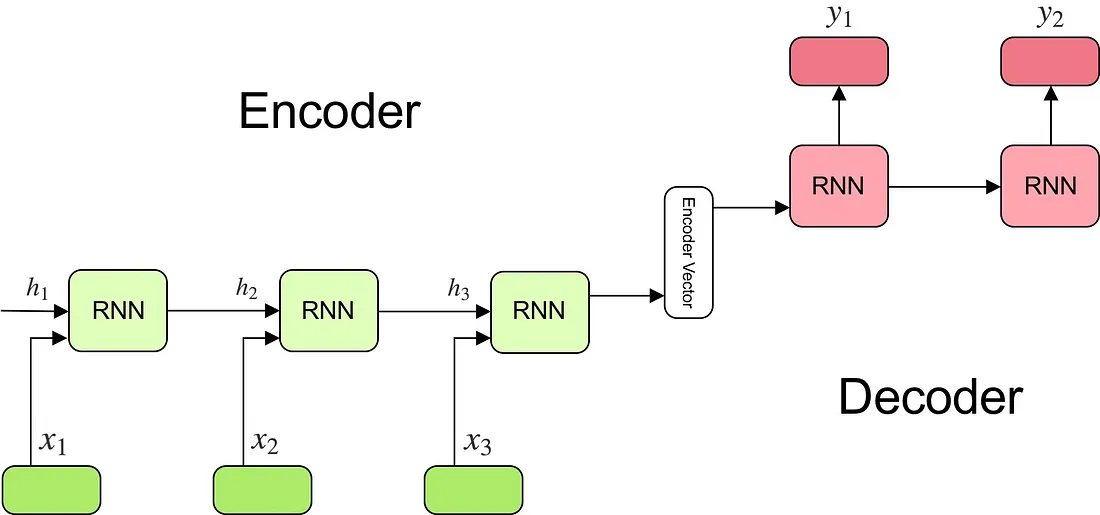

# Encoder–Decoder Architecture

---

### 🔹 Encoder
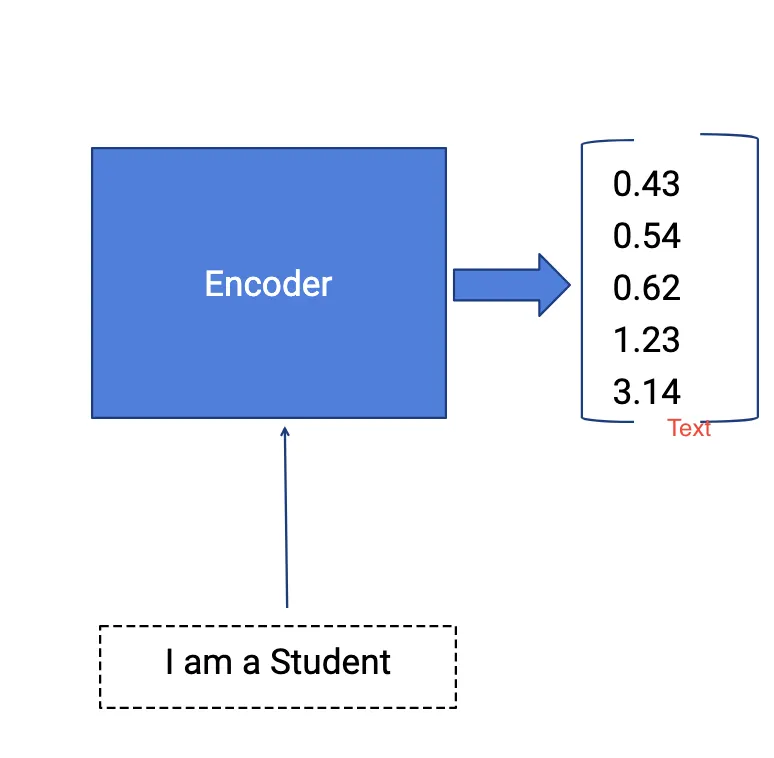



### **The hidden states $( h_i $) are computed using the formula:**

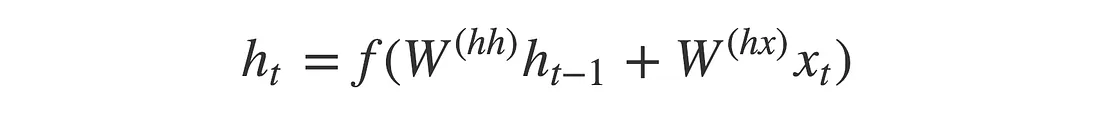

---

### 🔹 Decoder
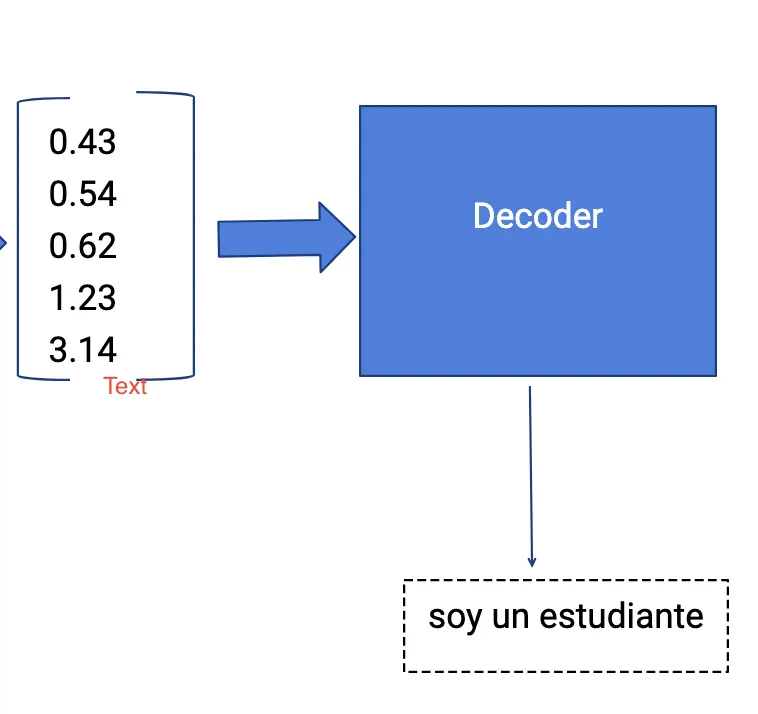

### **Any hidden state $( h_i $) is computed using the formula:**

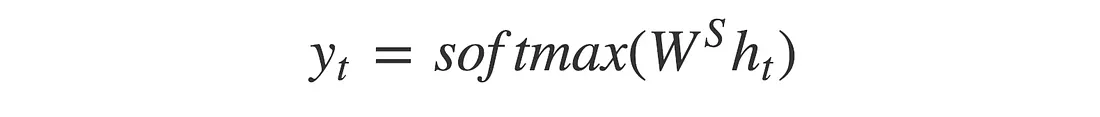

---



# Stage 2: Attention Mechanism (2015)

The Encoder–Decoder architecture worked well for small sentences but failed with long sequences.  
The main issue: **all information was compressed into a single fixed-length context vector**.  

As sentence length grew (e.g., >30 words), translation quality dropped drastically.  
Experiments showed that BLEU score (a translation quality metric) decreased as the number of input words increased.  
This highlighted the memory bottleneck of the vanilla encoder–decoder model.

---

## Problem Recap

- Encoder–Decoder compresses the entire input into a single **context vector**.  
- Decoder then generates output based only on this compressed vector.  
- For long sequences:  
  - Early words are forgotten due to **recency bias**.  
  - The context vector fails to represent the whole sentence properly.  
  - Translation loses accuracy and meaning.

---

## The Breakthrough: Attention

In 2015, researchers introduced the **Attention Mechanism** in the paper *“Neural Machine Translation by Jointly Learning to Align and Translate”*.  

The idea: instead of relying on a single fixed vector, the decoder should have access to **all encoder hidden states** at every decoding step.

---

## Core Idea of Attention

- Encoder still processes the input sequence and produces hidden states at each timestep.  
- Decoder does not depend only on the final state.  
- At each decoding step:
  - The decoder **looks back at all encoder hidden states**.  
  - An **attention layer** decides which hidden states are most relevant for predicting the current output word.  
  - A new **context vector** is dynamically computed for each output step.

---

## How Attention Works (Step by Step)

1. **Encoder phase**  
   - Input words are passed into the encoder LSTM one by one.  
   - At each timestep, a hidden state (h₁, h₂, h₃ …) is generated.  
   - All hidden states are stored.  

2. **Decoder phase with Attention**  
   - When predicting the first output word, the decoder looks at *all encoder hidden states*.  
   - The attention layer assigns **weights** to each hidden state depending on relevance.  
   - A weighted sum of hidden states forms the **context vector** for that step.  
   - This context vector + decoder state → generates the output word.  
   - For the next word, the process repeats with possibly different attention weights.  

3. **Dynamic Context**  
   - Unlike the vanilla model (single context vector), attention creates a **different context vector at each timestep**.  
   - This ensures the decoder can focus on the most relevant part of the input sequence for each output word.

---

## Benefits of Attention

- Handles **long sentences** more effectively.  
- Reduces memory loss — early words in the input are not forgotten.  
- Allows the model to “align” parts of the input sequence with corresponding output words.  
- Improves translation quality significantly compared to vanilla encoder–decoder models.

---

## Intuition

- Without attention:  
  - Decoder depends only on the **last encoder state**.  
  - Fails for long or complex sentences.  

- With attention:  
  - Decoder can **attend** to any encoder state as needed.  
  - Example: When translating the word “sadly,” the decoder focuses more on the hidden state corresponding to the first input word.  
  - This prevents missing context from the beginning, middle, or end of a sentence.

---

**Key takeaway:**  
Attention solved the biggest limitation of encoder–decoder models by letting the decoder selectively focus on relevant parts of the input sequence at each step. This was the foundation for the later development of the Transformer architecture.


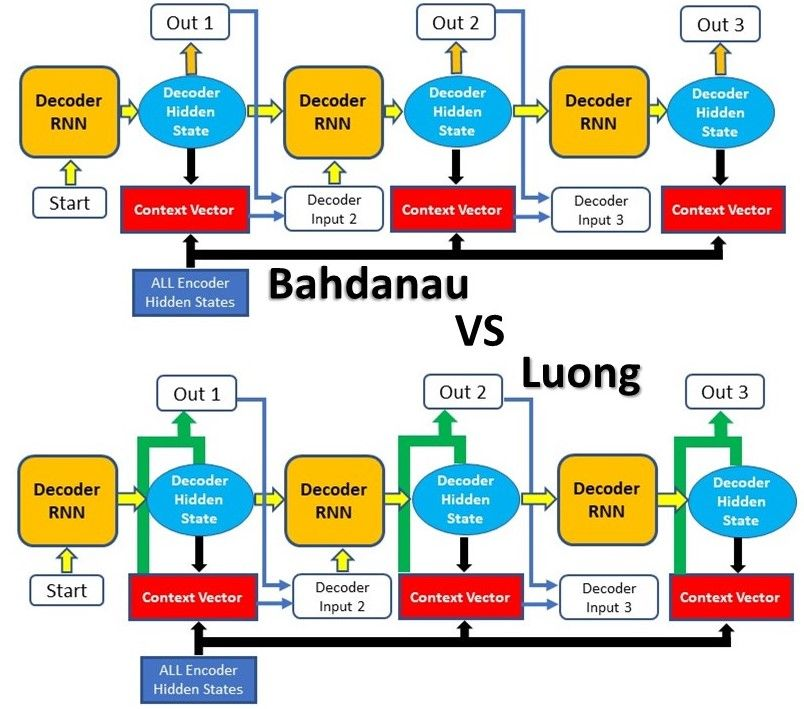

# Stage 3: Transformer Architecture (2017)


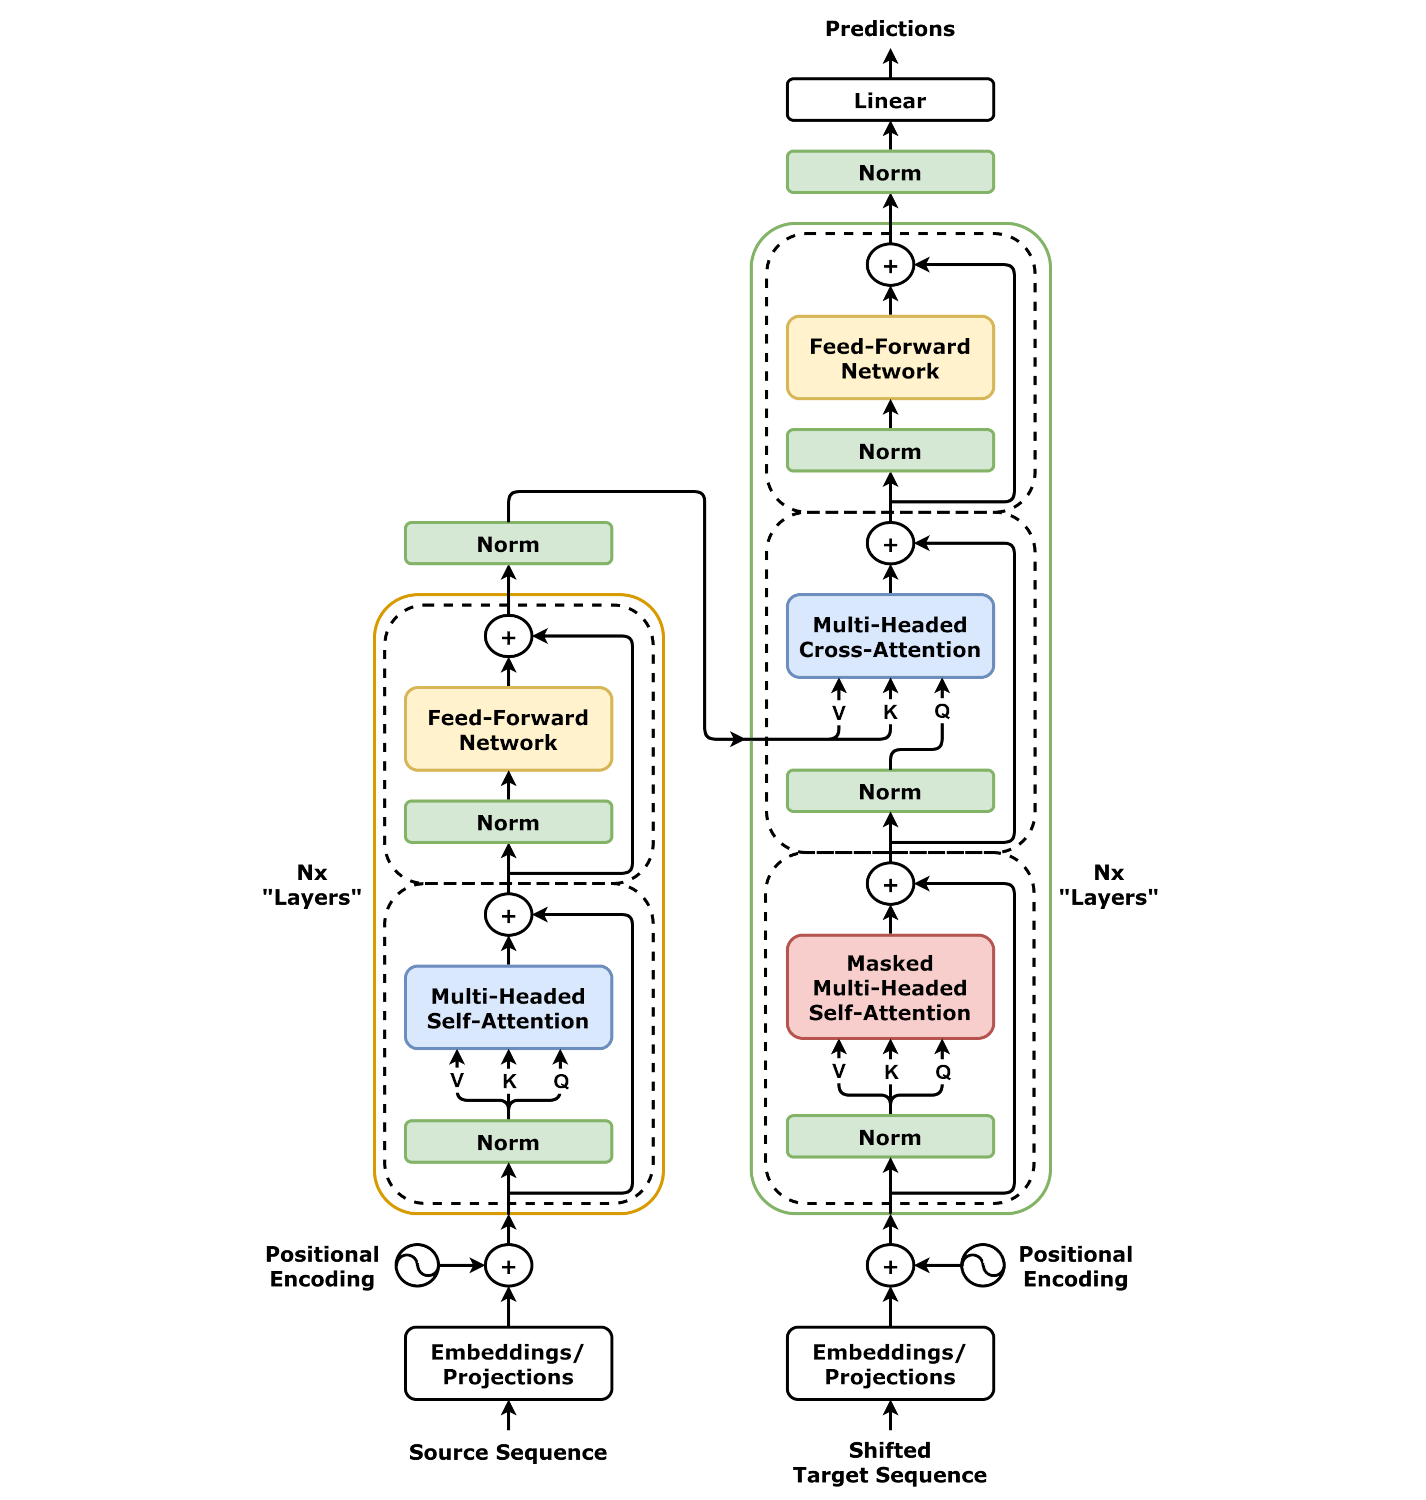


The Attention mechanism improved encoder–decoder models, but it introduced a major drawback.  
At every decoder timestep, a **separate context vector** had to be computed.  

This meant:
- For each output word, similarity scores were calculated with *all input words*.  
- If the input length is **N** and output length is **M**, then attention requires **N × M computations**.  
- This results in **quadratic complexity**.  

As sequences became longer, training slowed down drastically.  
Researchers realized that the main problem was not attention itself, but the **use of LSTMs/RNNs**, which process inputs **sequentially** (one word at a time). This sequential nature prevented parallelization.

---

## The Breakthrough: Transformers

In 2017, Google Brain introduced a groundbreaking paper:  
**“Attention Is All You Need”**.  

This was the first time the **Transformer architecture** was proposed, which completely changed the landscape of NLP.

Key innovations:
- **No LSTMs or RNNs** – the architecture entirely dropped recurrent networks.  
- Introduced a new form of attention: **Self-Attention**.  
- Enabled **parallel processing** of input words instead of one-by-one sequential processing.  

---

## Encoder–Decoder in Transformers

The architecture still follows an encoder–decoder design, but with major changes:
- **Encoder block**: uses self-attention + feed-forward (dense) layers.  
- **Decoder block**: uses self-attention + encoder–decoder attention + feed-forward layers.  
- Additional components: embeddings, normalization layers, residual connections.  

Unlike RNN-based models, all input words can be **seen simultaneously**, enabling parallelization.

---

## Advantages of Transformers

1. **Parallelization**  
   - Input words are processed together.  
   - Training becomes much faster.  

2. **Efficiency**  
   - Reduced training time compared to LSTMs with attention.  
   - Lower hardware requirements.  

3. **State-of-the-art results**  
   - When trained properly, transformers consistently achieve top results across NLP tasks.  

---

## Challenges with Transformers

- **High resource requirements**  
  - Still need powerful GPUs for large-scale training.  
  - Expensive compared to smaller models.  

- **Time**  
  - Faster than LSTMs, but training still takes significant time depending on dataset size.  

- **Data hunger**  
  - Training from scratch requires *very large datasets*.  
  - Example: even for sentiment analysis, hundreds of thousands to millions of examples may be needed.  
  - With small datasets (e.g., only a few hundred or thousand samples), training from scratch does not yield good results.  

---

## Why Transformers Were a Revolution

Transformers introduced a **scalable, parallelizable, and attention-driven** architecture.  
This became the foundation of modern NLP and LLMs.  

However, training from scratch was difficult for most practitioners due to **hardware, time, and data constraints**.  
To overcome this, the next stage in history introduced **Transfer Learning** in NLP — a solution that made transformers widely usable even with limited data.

---


# Stage 4: Transfer Learning in NLP – ULMFiT (2018)

In 2018, a landmark paper introduced the idea of applying **transfer learning to NLP**.  
The approach was called **ULMFiT** (Universal Language Model Fine-Tuning).  
This was revolutionary because, until then, transfer learning was mainly successful in **computer vision**, but not in NLP.

---

## Quick Recap: What is Transfer Learning?

Transfer Learning is a technique where **knowledge gained from one task** is reused to improve performance on a **related task**.

- Example: If a model learns to recognize cars, it can transfer some of that knowledge to recognize trucks.  
- Humans also do this: learning to ride a bicycle makes learning to ride a motorbike easier.

Transfer Learning usually has two steps:

1. **Pretraining**  
   - Train a model on a large, universal dataset.  
   - Goal: learn general features (e.g., shapes, edges in images).  

2. **Fine-tuning**  
   - Take the pretrained model.  
   - Retain the early weights but replace/update later layers with new ones.  
   - Train on a smaller, task-specific dataset.  
   - Example: Fine-tune an ImageNet-pretrained CNN to classify cats vs dogs with only 100 images.

---

## Why Transfer Learning Didn’t Work in NLP Before 2018

1. **Task Specificity**  
   - NLP tasks (sentiment analysis, NER, POS tagging, machine translation, summarization, QA, etc.) seemed very different.  
   - It was assumed that no single model could learn language basics and generalize across all tasks.

2. **Lack of Data**  
   - Previous attempts used **machine translation** for pretraining.  
   - Translation requires **parallel corpora** (sentence pairs in two languages).  
   - Such large labeled datasets were scarce and expensive to build.  

Because of these two challenges, transfer learning could not establish itself in NLP until ULMFiT.

---

## ULMFiT: The Breakthrough

ULMFiT proposed a new framework for NLP transfer learning by using **Language Modeling** instead of translation as the pretraining task.

### What is Language Modeling?  
- Task: predict the next word in a sentence.  
- Example:  
  - Input: *The capital of India is …*  
  - Model prediction: *Delhi*.  
- This task teaches a model to capture grammar, semantics, and even common sense patterns.

---

## Why Language Modeling Works Well

1. **Rich Feature Learning**  
   - Although predicting the next word seems simple, the model learns:  
     - Grammar and syntax.  
     - Sentence semantics and meaning.  
     - Contextual clues and even commonsense knowledge.  
   - Example: *The hotel was exceptionally clean, yet the service was …* → model learns that a negative word like *bad* should follow.

2. **Huge Availability of Data**  
   - Unlike translation, language modeling doesn’t require labeled data.  
   - Any text corpus (books, Wikipedia, articles, PDFs) can be used.  
   - Hence, pretraining becomes **unsupervised** and scalable to massive datasets.

---

## The ULMFiT Setup

- Model: a variant of LSTM called **AWD-LSTM** (state-of-the-art at the time).  
- Pretraining: performed on **Wikipedia text** using the language modeling task (predict next word).  
- Fine-tuning:  
  - Replace the output layer with a task-specific classifier.  
  - Train on small labeled datasets like IMDB reviews, sentiment analysis, or news classification.  
- Results:  
  - Outperformed models trained from scratch.  
  - Example: A scratch model needed **10,000 rows** for good results.  
    ULMFiT achieved **better performance with only 100 rows** through fine-tuning.

---

## Why ULMFiT was Revolutionary

- Proved that **transfer learning is possible in NLP**.  
- Showed that **unsupervised pretraining with language modeling** provides a universal representation of language.  
- Made it possible to achieve state-of-the-art performance on small datasets.  

---

## Context in 2018

- By 2018, two powerful technologies had emerged:  
  1. **Transformers (2017)** – architectural breakthrough.  
  2. **ULMFiT (2018)** – training breakthrough using transfer learning.  

This combination hinted at the next revolution: applying transfer learning on top of transformer models, which led to modern pretrained language models.

---


# Stage 5: Rise of Transformer-based Language Models and LLMs (2018 onwards)

In 2018, around 10 months after the ULMFiT paper, two new language models were released based on the **Transformer architecture**. Both were **language models**, meaning they were trained for the task of **next-word prediction**.  

The key difference was:
- **BERT** → Encoder-only model  
- **GPT** → Decoder-only model  

Despite this difference, both demonstrated the power of transfer learning in NLP. They could be fine-tuned for multiple downstream tasks:
- Sentiment analysis  
- Named Entity Recognition (NER)  
- Part-of-speech tagging  
- Question answering  
- Text summarization  

This was revolutionary because anyone could now download these pretrained models, fine-tune them on their own limited dataset, and achieve **state-of-the-art results**.

---

## The Evolution After 2018

- OpenAI continued improving GPT with successive versions (GPT-2, GPT-3, etc.).  
- These models became increasingly larger, with more parameters and trained on massive datasets.  
- Their performance was so powerful that the community started calling them **Large Language Models (LLMs)** instead of just "language models".

---

## When Does a Language Model Become an LLM?

A language model is considered an **LLM** when it satisfies certain characteristics:

### 1. Data
- Trained on **extremely large datasets**, often billions of words.  
- Example: GPT-3 was trained on ~45 TB of text sourced from books, websites, and the broader internet (e.g., Reddit).  
- **Diversity of data** is emphasized to minimize bias.

### 2. Hardware
- Requires clusters of GPUs for distributed training.  
- Example: GPT-3 was trained using a supercomputer with thousands of NVIDIA GPUs.  
- Also demands large memory and high-speed networking.

### 3. Training Time
- Training on massive datasets can take **days to weeks**, even with powerful hardware.  
- Time depends on dataset size, model parameters, and compute resources.

### 4. Cost
- Extremely expensive due to:  
  - Hardware infrastructure  
  - Electricity and energy costs  
  - Distributed computing setup  
  - Hiring domain experts  
- Training such models typically costs **millions of dollars**, making it feasible only for large companies, governments, or major research institutes.

### 5. Energy Consumption
- Training consumes a **huge amount of energy**.  
- For example, training GPT-3 (175B parameters) required as much energy as what a **small city consumes in a month**.  
- This has led to growing discussions about the environmental impact of training LLMs.

---

## BERT vs GPT: Key Differences

| Aspect              | BERT (2018)                        | GPT (2018)                         |
|---------------------|-------------------------------------|-------------------------------------|
| Architecture        | Encoder-only (Transformer)          | Decoder-only (Transformer)          |
| Training Objective  | Masked Language Modeling (MLM) + Next Sentence Prediction (NSP) | Next-word prediction (causal LM)    |
| Training Style      | Bidirectional context (looks both left and right) | Unidirectional (left-to-right)      |
| Strengths           | Strong for understanding tasks like NER, classification, QA | Strong for text generation, story completion, dialogue |
| Limitation          | Not designed for text generation    | Less effective for deep bidirectional understanding |

---

## The Beginning of the LLM Era

From 2018 onwards, with the advent of BERT and GPT, NLP underwent a complete transformation:
- **Architecture innovation**: Transformer-based models.  
- **Training innovation**: Transfer learning applied at scale.  
- **Impact**: Enabled anyone with a dataset to fine-tune powerful pretrained models and achieve state-of-the-art results.  

This marked the **start of the LLM era**, which continues to shape today’s AI landscape.

---


# From GPT-3 to ChatGPT

So far, we have covered the history. Now let’s talk about the **present**, which is **ChatGPT**. Many people confuse GPT and ChatGPT, so let’s clarify:

- **GPT** is a **model**.  
- **ChatGPT** is an **application** (a chatbot) built on top of GPT.  

A simple analogy:  
- Think of a laptop. The **laptop** may be HP, but the **processor** inside could be Intel.  
- Similarly, ChatGPT is the application (like HP laptop), and GPT is the underlying model (like Intel processor).  
- Using GPT, many applications can be built, such as **Bard** or **Jasper**, but **ChatGPT** is the most famous one.

ChatGPT was released in **November 2022**, and it quickly became a global sensation because of its human-like conversational ability.

---

## How GPT-3 Was Transformed into ChatGPT

To build ChatGPT from GPT-3, OpenAI made several key modifications:

### 1. Reinforcement Learning from Human Feedback (RLHF)
- This is the **core idea** behind ChatGPT’s success.  
- The process involves two steps:
  - **Supervised Fine-Tuning**:  
    - A large labeled dataset of human conversations was collected.  
    - For each input, the expected output (human-like response) was provided.  
    - GPT-3 was fine-tuned on this data to better align with conversational patterns.
  - **Reinforcement Learning**:  
    - ChatGPT was prompted with inputs and generated multiple responses.  
    - Human evaluators ranked the responses from best to worst.  
    - This ranking was used as feedback to improve the model’s behavior.  

### 2. Safety and Ethical Guidelines
- ChatGPT was explicitly trained to **avoid harmful or inappropriate outputs**.  
- For example, it will refuse to explain dangerous activities like making a bomb.  
- Data was carefully sourced to reduce biases and encourage safer outputs.

### 3. Improved Context Handling
- Unlike GPT-3, which often forgot earlier parts of a conversation, ChatGPT was designed to **retain context across multiple turns**.  
- This makes it much better for dialogue and natural conversations.

### 4. Dialogue-Specific Training
- GPT models (GPT-1, GPT-2, GPT-3) were trained mainly for **next-word prediction**.  
- ChatGPT, however, was trained on **conversation-heavy datasets**.  
- As a result, it understands **human dialogue patterns** more effectively and generates more natural responses.

### 5. Continuous Improvement via User Feedback
- OpenAI has been **iteratively improving** ChatGPT since launch.  
- Features like thumbs-up/thumbs-down allow users to give feedback.  
- At times, ChatGPT even provided multiple answers and asked users to choose the best one.  
- This ongoing feedback loop has helped refine and improve the product.

---

## Summary

- **GPT = model**, **ChatGPT = application** built on GPT.  
- ChatGPT was created by adding **RLHF**, **safety mechanisms**, **context retention**, and **dialogue-specific training** on top of GPT-3.  
- It continues to improve through **user feedback and fine-tuning**.  

This marks the transformation from a **powerful language model (GPT-3)** into a **usable, safe, and conversational AI application (ChatGPT)**.

---
